# IEEE-CIS Fraud Detection - Notebook Metodologi Final

Notebook ini merapikan alur eksperimen final untuk presentasi kode tugas akhir.
Fokus metodologi:

- dataset IEEE-CIS: `train_transaction` digabung dengan `train_identity`;
- split stratified holdout 60/20/20 dengan `random_state=42`;
- prapemrosesan A1: frequency encoding, median imputation, dan z-score normalization;
- sensitivity analysis pada validation untuk mengunci `latent_dim` dan `target_fraud_rate`;
- tiga skenario utama: baseline LightGBM, SMOTE + LightGBM, dan AE latent-space oversampling + LightGBM;
- setiap skenario dijalankan dalam versi default dan tuned dengan Optuna/TPE;
- evaluasi utama memakai PR-AUC/Average Precision, dengan ROC-AUC, Precision, Recall, dan F1-score sebagai metrik pendukung.

Notebook ini sengaja tidak memakai MCC, bootstrap, atau confusion matrix sebagai output utama agar selaras dengan metrik yang dijelaskan di Bab 2.

## Anchor metodologi

Ringkasan anchor yang dipakai dalam eksperimen:

- **LightGBM**: model klasifikasi tabular utama.
- **SMOTE**: pembanding oversampling klasik pada ruang fitur A1.
- **Autoencoder latent-space oversampling**: kontribusi utama, yaitu membuat sampel fraud sintetis melalui interpolasi di latent space lalu didekode kembali ke ruang fitur.
- **Sensitivity analysis**: `latent_dim` dan `target_fraud_rate` dipilih berdasarkan PR-AUC validation agar angka final tidak arbitrer.
- **Optuna/TPE**: pencarian hyperparameter LightGBM berdasarkan PR-AUC validation.
- **PR-AUC/Average Precision**: metrik utama karena data fraud sangat tidak seimbang.

Aturan penting: semua transformasi, oversampling, AE, tuning, early stopping, sensitivity analysis, dan threshold selection hanya memakai data train/validation. Data test hanya dipakai untuk evaluasi akhir.

## 0. Import library dan konfigurasi awal

Cell ini menyiapkan library, seed, lokasi data, dan folder output. Notebook bisa dijalankan di Kaggle atau secara lokal dari repo selama file IEEE-CIS tersedia.

In [1]:
from __future__ import annotations

import json
import os
import random
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

import lightgbm as lgb
import optuna
import tensorflow as tf
from tensorflow import keras

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("default")

In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Kolom utama IEEE-CIS
TARGET_COL = "isFraud"
ID_COL = "TransactionID"

# Split aktif skripsi
TRAIN_RATIO = 0.60
VALID_RATIO = 0.20
TEST_RATIO = 0.20

# Grid sensitivity analysis untuk mengunci parameter metode
LATENT_GRID = [8, 16, 32, 64]
RATE_GRID = [0.10, 0.15, 0.20, 0.30, 0.50]
SENS_N_ESTIMATORS = 800

# Parameter AE dan SMOTE
K_NEIGHBORS = 5
AE_EPOCHS = 60
AE_BATCH_SIZE = 256
AE_PATIENCE = 8
AE_LEARNING_RATE = 1e-3
ZSCORE_CLIP = 10.0  

# Parameter LightGBM dan tuning
N_ESTIMATORS = 2000
EARLY_STOPPING_ROUNDS = 100
N_TRIALS = 10
RUN_TUNING = True


def find_repo_root(start: Path) -> Path:
    """Find repo root from current notebook location."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
DATA_CANDIDATES = [
    Path("/kaggle/input/ieee-fraud-detection"),
    Path("/kaggle/input/competitions/ieee-fraud-detection"),
    REPO_ROOT / "data" / "raw",
]
DATA_DIR = next(
    (path for path in DATA_CANDIDATES if (path / "train_transaction.csv").exists()),
    REPO_ROOT / "data" / "raw",
)

OUTPUT_DIR = (
    Path("/kaggle/working/final_methodology_notebook")
    if Path("/kaggle/working").exists()
    else REPO_ROOT / "outputs" / "notebook_final_methodology"
)
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root : {REPO_ROOT}")
print(f"Data dir  : {DATA_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Repo root : C:\Users\Lenovo\Documents\1_TugasAkhir\ecommerce_fraud_detection
Data dir  : C:\Users\Lenovo\Documents\1_TugasAkhir\ecommerce_fraud_detection\data\raw
Output dir: C:\Users\Lenovo\Documents\1_TugasAkhir\ecommerce_fraud_detection\outputs\notebook_final_methodology


## 1. Load dan gabung data

Data transaksi menjadi tabel utama. Data identity digabung dengan left join berdasarkan `TransactionID` agar seluruh transaksi tetap dipertahankan.

In [3]:
def load_ieee_cis_data(data_dir: Path) -> pd.DataFrame:
    transaction_path = data_dir / "train_transaction.csv"
    identity_path = data_dir / "train_identity.csv"

    if not transaction_path.exists() or not identity_path.exists():
        raise FileNotFoundError(
            "File IEEE-CIS tidak ditemukan. Pastikan train_transaction.csv dan "
            f"train_identity.csv tersedia di: {data_dir}"
        )

    transaction_df = pd.read_csv(transaction_path)
    identity_df = pd.read_csv(identity_path)
    merged_df = transaction_df.merge(identity_df, on=ID_COL, how="left")

    if merged_df[ID_COL].duplicated().any():
        raise ValueError("TransactionID duplikat ditemukan setelah merge.")
    if merged_df[TARGET_COL].isna().any():
        raise ValueError("Target isFraud mengandung nilai kosong.")

    return merged_df


full_df = load_ieee_cis_data(DATA_DIR)
print(f"Shape data gabungan: {full_df.shape}")
display(full_df[[ID_COL, TARGET_COL]].head())

Shape data gabungan: (590540, 434)


,TransactionID,isFraud
0,2987000,0
1,2987001,0
2,2987002,0
3,2987003,0
4,2987004,0


## 2. Split stratified 60/20/20

Split dilakukan sebelum prapemrosesan dan sebelum oversampling. Tujuannya agar tidak ada informasi dari validation/test yang ikut mempengaruhi proses training.

In [4]:
def stratified_60_20_20_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    y = df[TARGET_COL].to_numpy()
    row_idx = np.arange(len(df))

    train_idx, temp_idx = train_test_split(
        row_idx,
        test_size=(VALID_RATIO + TEST_RATIO),
        stratify=y,
        random_state=SEED,
    )
    valid_idx, test_idx = train_test_split(
        temp_idx,
        test_size=TEST_RATIO / (VALID_RATIO + TEST_RATIO),
        stratify=y[temp_idx],
        random_state=SEED,
    )

    train_df = df.iloc[train_idx].reset_index(drop=True).copy()
    valid_df = df.iloc[valid_idx].reset_index(drop=True).copy()
    test_df = df.iloc[test_idx].reset_index(drop=True).copy()

    train_ids = set(train_df[ID_COL])
    valid_ids = set(valid_df[ID_COL])
    test_ids = set(test_df[ID_COL])
    assert train_ids.isdisjoint(valid_ids)
    assert train_ids.isdisjoint(test_ids)
    assert valid_ids.isdisjoint(test_ids)

    return train_df, valid_df, test_df


def summarize_split(*, train_df: pd.DataFrame, valid_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for name, split_df in [("train", train_df), ("validation", valid_df), ("test", test_df)]:
        fraud_count = int(split_df[TARGET_COL].sum())
        rows.append(
            {
                "split": name,
                "rows": int(len(split_df)),
                "fraud_count": fraud_count,
                "fraud_rate": fraud_count / len(split_df),
            }
        )
    return pd.DataFrame(rows)


train_df, valid_df, test_df = stratified_60_20_20_split(full_df)
split_summary_df = summarize_split(train_df=train_df, valid_df=valid_df, test_df=test_df)
display(split_summary_df)

,split,rows,fraud_count,fraud_rate
0,train,354324,12398,0.034991
1,validation,118108,4133,0.034993
2,test,118108,4132,0.034985


## 3. Prapemrosesan A1: frequency encoding, median imputation, z-score

Kontrak prapemrosesan:

- `TransactionID` dan `isFraud` tidak menjadi fitur;
- fitur kategorikal diubah menjadi frekuensi kategori berdasarkan data train;
- nilai kategorikal kosong diberi token khusus `__MISSING__`;
- kategori baru di validation/test diberi frekuensi 0;
- fitur numerik diisi dengan median train;
- fitur numerik dinormalisasi dengan rata-rata dan standar deviasi train;
- statistik prapemrosesan dihitung hanya dari data train.

Catatan: beberapa fitur IEEE-CIS seperti `card1-card6`, `addr1`, dan `addr2` berisi kode kategori walaupun bertipe numerik. Di notebook ini kolom tersebut tetap diperlakukan sebagai kategorikal agar frequency encoding lebih konsisten dengan karakteristik data.

In [5]:
MISSING_TOKEN = "__MISSING__"
IEEE_CATEGORICAL = (
    {
        "ProductCD",
        "card1", "card2", "card3", "card4", "card5", "card6",
        "addr1", "addr2",
        "P_emaildomain", "R_emaildomain",
        "DeviceType", "DeviceInfo",
    }
    | {f"M{i}" for i in range(1, 10)}
    | {f"id_{i:02d}" for i in range(12, 39)}
)


def feature_frame(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=[ID_COL, TARGET_COL]).copy()


def detect_categorical_columns(X: pd.DataFrame) -> list[str]:
    dtype_cats = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    ieee_cats = [column for column in IEEE_CATEGORICAL if column in X.columns]
    categories = set(dtype_cats).union(ieee_cats)
    return sorted(categories, key=lambda column: X.columns.get_loc(column))


def normalize_category(series: pd.Series) -> pd.Series:
    return series.astype("string").fillna(MISSING_TOKEN).astype(str)


def fit_a1_preprocessor(X_train: pd.DataFrame) -> dict:
    feature_columns = X_train.columns.tolist()
    categorical_columns = detect_categorical_columns(X_train)
    numeric_columns = [column for column in feature_columns if column not in categorical_columns]

    numeric_train = X_train[numeric_columns].apply(pd.to_numeric, errors="coerce")
    numeric_medians = numeric_train.median(axis=0, skipna=True).fillna(0.0)
    numeric_imputed = numeric_train.fillna(numeric_medians)
    numeric_means = numeric_imputed.mean(axis=0).fillna(0.0)
    numeric_stds = numeric_imputed.std(axis=0, ddof=0).replace(0.0, np.nan).fillna(1.0)

    frequency_maps = {}
    n_rows = float(len(X_train))
    for column in categorical_columns:
        values = normalize_category(X_train[column])
        frequency_maps[column] = (values.value_counts(dropna=False) / n_rows).to_dict()

    transformed_columns = numeric_columns + [f"{column}_frequency" for column in categorical_columns]
    return {
        "feature_columns": feature_columns,
        "numeric_columns": numeric_columns,
        "categorical_columns": categorical_columns,
        "transformed_columns": transformed_columns,
        "numeric_medians": numeric_medians.to_dict(),
        "numeric_means": numeric_means.to_dict(),
        "numeric_stds": numeric_stds.to_dict(),
        "frequency_maps": frequency_maps,
        "zscore_clip": ZSCORE_CLIP,
        "fit_scope": "train split only",
    }


def apply_a1_preprocessor(X: pd.DataFrame, preprocessor: dict) -> pd.DataFrame:
    X = X.loc[:, preprocessor["feature_columns"]].copy()
    numeric_columns = preprocessor["numeric_columns"]
    categorical_columns = preprocessor["categorical_columns"]

    parts = []
    if numeric_columns:
        numeric = X[numeric_columns].apply(pd.to_numeric, errors="coerce")
        medians = pd.Series(preprocessor["numeric_medians"])
        means = pd.Series(preprocessor["numeric_means"])
        stds = pd.Series(preprocessor["numeric_stds"])
        numeric = numeric.fillna(medians)
        numeric = (numeric - means) / stds
        if preprocessor["zscore_clip"] is not None:
            numeric = numeric.clip(-preprocessor["zscore_clip"], preprocessor["zscore_clip"])
        parts.append(numeric.astype("float32"))

    if categorical_columns:
        encoded = {}
        for column in categorical_columns:
            values = normalize_category(X[column])
            mapping = preprocessor["frequency_maps"][column]
            encoded[f"{column}_frequency"] = values.map(mapping).fillna(0.0).astype("float32")
        parts.append(pd.DataFrame(encoded, index=X.index))

    transformed = pd.concat(parts, axis=1)
    transformed = transformed.loc[:, preprocessor["transformed_columns"]]
    values = transformed.to_numpy(dtype="float32")
    if not np.isfinite(values).all():
        raise ValueError("Prapemrosesan A1 menghasilkan nilai non-finite.")
    return transformed


X_train_raw = feature_frame(train_df)
X_valid_raw = feature_frame(valid_df)
X_test_raw = feature_frame(test_df)

y_train = train_df[TARGET_COL].astype(int).to_numpy()
y_valid = valid_df[TARGET_COL].astype(int).to_numpy()
y_test = test_df[TARGET_COL].astype(int).to_numpy()

a1_preprocessor = fit_a1_preprocessor(X_train_raw)
X_train = apply_a1_preprocessor(X_train_raw, a1_preprocessor)
X_valid = apply_a1_preprocessor(X_valid_raw, a1_preprocessor)
X_test = apply_a1_preprocessor(X_test_raw, a1_preprocessor)

print(f"Fitur mentah      : {len(a1_preprocessor['feature_columns'])}")
print(f"Fitur numerik     : {len(a1_preprocessor['numeric_columns'])}")
print(f"Fitur kategorikal : {len(a1_preprocessor['categorical_columns'])}")
print(f"Fitur A1 akhir    : {X_train.shape[1]}")
print(f"Shape train/valid/test: {X_train.shape}, {X_valid.shape}, {X_test.shape}")

Fitur mentah      : 432
Fitur numerik     : 383
Fitur kategorikal : 49
Fitur A1 akhir    : 432
Shape train/valid/test: (354324, 432), (118108, 432), (118108, 432)


## 4. Helper evaluasi dan LightGBM

Threshold klasifikasi dipilih dari data validation dengan F1-score. Setelah threshold terkunci, performa akhir dihitung di data test.

In [6]:
def set_all_seeds(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def average_precision_eval(y_true: np.ndarray, y_score: np.ndarray):
    return "average_precision", average_precision_score(y_true, y_score), True


def default_lgbm_params(scale_pos_weight: float) -> dict:
    return {
        "objective": "binary",
        "boosting_type": "gbdt",
        "n_estimators": N_ESTIMATORS,
        "learning_rate": 0.03,
        "num_leaves": 64,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.8,
        "subsample_freq": 1,
        "colsample_bytree": 0.8,
        "scale_pos_weight": scale_pos_weight,
        "n_jobs": -1,
        "random_state": SEED,
        "metric": "None",
        "verbosity": -1,
    }


def fit_lgbm(
    X_tr,
    y_tr: np.ndarray,
    X_va,
    y_va: np.ndarray,
    params: dict,
) -> tuple[lgb.LGBMClassifier, int]:
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric=average_precision_eval,
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    best_iteration = int(model.best_iteration_ or params.get("n_estimators", N_ESTIMATORS))
    return model, best_iteration


def tune_lgbm(
    name: str,
    X_tr,
    y_tr: np.ndarray,
    X_va,
    y_va: np.ndarray,
    scale_pos_weight: float,
) -> tuple[lgb.LGBMClassifier, int, dict]:
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="maximize", sampler=sampler)

    def objective(trial: optuna.Trial) -> float:
        params = default_lgbm_params(scale_pos_weight)
        params.update(
            {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 16, 256),
                "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            }
        )
        model, best_iteration = fit_lgbm(X_tr, y_tr, X_va, y_va, params)
        valid_score = model.predict_proba(X_va, num_iteration=best_iteration)[:, 1]
        return average_precision_score(y_va, valid_score)

    print(f"Tuning {name} dengan {N_TRIALS} trial Optuna/TPE...")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    best_params = default_lgbm_params(scale_pos_weight)
    best_params.update(study.best_params)
    model, best_iteration = fit_lgbm(X_tr, y_tr, X_va, y_va, best_params)
    info = {
        "best_validation_average_precision": float(study.best_value),
        "best_iteration": best_iteration,
        "best_params": study.best_params,
    }
    return model, best_iteration, info


def select_threshold_by_f1(y_true: np.ndarray, y_score: np.ndarray) -> tuple[float, pd.DataFrame]:
    rows = []
    for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2):
        y_pred = (y_score >= threshold).astype(int)
        rows.append(
            {
                "threshold": float(threshold),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    table = pd.DataFrame(rows)
    best_index = table.sort_values(
        ["f1", "recall", "threshold"],
        ascending=[False, False, True],
    ).index[0]
    table["selected"] = False
    table.loc[best_index, "selected"] = True
    return float(table.loc[best_index, "threshold"]), table


def evaluate_model_scores(
    scenario: str,
    y_va: np.ndarray,
    valid_score: np.ndarray,
    y_te: np.ndarray,
    test_score: np.ndarray,
) -> tuple[dict, pd.DataFrame]:
    threshold, threshold_table = select_threshold_by_f1(y_va, valid_score)
    test_pred = (test_score >= threshold).astype(int)
    metrics = {
        "scenario": scenario,
        "average_precision": float(average_precision_score(y_te, test_score)),
        "roc_auc": float(roc_auc_score(y_te, test_score)),
        "precision": float(precision_score(y_te, test_pred, zero_division=0)),
        "recall": float(recall_score(y_te, test_pred, zero_division=0)),
        "f1": float(f1_score(y_te, test_pred, zero_division=0)),
        "selected_threshold": threshold,
    }
    return metrics, threshold_table

## 5. Helper oversampling

SMOTE membuat sampel sintetis dengan interpolasi antar sampel fraud pada ruang fitur A1. AE latent-space oversampling melakukan interpolasi di latent space Autoencoder, lalu hasil latent sintetis didekode kembali menjadi fitur A1 sintetis.

In [7]:
def synthetic_count_for_target_rate(y: np.ndarray, target_rate: float) -> int:
    n_fraud = int((y == 1).sum())
    n_normal = int((y == 0).sum())
    n_synthetic = (target_rate * n_normal / (1.0 - target_rate)) - n_fraud
    return max(0, int(round(n_synthetic)))


def smote_interpolation(
    minority_points: np.ndarray,
    n_synthetic: int,
    k_neighbors: int,
    rng: np.random.Generator,
) -> np.ndarray:
    if n_synthetic <= 0 or len(minority_points) < 2:
        return np.empty((0, minority_points.shape[1]), dtype="float32")

    n_neighbors = min(k_neighbors + 1, len(minority_points))
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(minority_points)
    _, neighbor_idx = nn.kneighbors(minority_points)

    anchors = rng.integers(0, len(minority_points), size=n_synthetic)
    synthetic = np.empty((n_synthetic, minority_points.shape[1]), dtype="float32")

    for i, anchor in enumerate(anchors):
        candidates = neighbor_idx[anchor][1:]
        neighbor = candidates[rng.integers(0, len(candidates))]
        lam = rng.random()
        synthetic[i] = minority_points[anchor] + lam * (minority_points[neighbor] - minority_points[anchor])

    return synthetic


def build_fraud_autoencoder(input_dim: int, latent_dim: int):
    input_layer = keras.Input(shape=(input_dim,), name="input")
    enc_128 = keras.layers.Dense(128, activation="relu", name="enc_dense_128")(input_layer)
    enc_64 = keras.layers.Dense(64, activation="relu", name="enc_dense_64")(enc_128)
    latent = keras.layers.Dense(latent_dim, activation="linear", name="latent")(enc_64)

    dec_64_layer = keras.layers.Dense(64, activation="relu", name="dec_dense_64")
    dec_128_layer = keras.layers.Dense(128, activation="relu", name="dec_dense_128")
    output_layer = keras.layers.Dense(input_dim, activation="linear", name="reconstruction")

    dec_64 = dec_64_layer(latent)
    dec_128 = dec_128_layer(dec_64)
    reconstruction = output_layer(dec_128)

    autoencoder = keras.Model(input_layer, reconstruction, name="fraud_autoencoder")
    encoder = keras.Model(input_layer, latent, name="fraud_encoder")

    latent_input = keras.Input(shape=(latent_dim,), name="latent_input")
    decoder_output = output_layer(dec_128_layer(dec_64_layer(latent_input)))
    decoder = keras.Model(latent_input, decoder_output, name="fraud_decoder")

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=AE_LEARNING_RATE),
        loss="mse",
    )
    return autoencoder, encoder, decoder


def append_synthetic_fraud(
    X_base: pd.DataFrame,
    y_base: np.ndarray,
    synthetic_points: np.ndarray,
) -> tuple[pd.DataFrame, np.ndarray]:
    synthetic_df = pd.DataFrame(synthetic_points, columns=X_base.columns)
    X_augmented = pd.concat([X_base.reset_index(drop=True), synthetic_df], ignore_index=True)
    y_augmented = np.concatenate([y_base, np.ones(len(synthetic_df), dtype=int)])
    return X_augmented.astype("float32"), y_augmented


fraud_train_dense = X_train.loc[y_train == 1].to_numpy(dtype="float32")
print(f"Fraud train asli     : {(y_train == 1).sum():,}")
print(f"Non-fraud train asli : {(y_train == 0).sum():,}")
print(f"Grid latent_dim      : {LATENT_GRID}")
print(f"Grid fraud rate      : {RATE_GRID}")

Fraud train asli     : 12,398
Non-fraud train asli : 341,926
Grid latent_dim      : [8, 16, 32, 64]
Grid fraud rate      : [0.1, 0.15, 0.2, 0.3, 0.5]


## 6. Analisis sensitivitas parameter metode

- `latent_dim`: kapasitas representasi laten Autoencoder;
- `target_fraud_rate`: rasio fraud setelah oversampling pada data train.

Grid dievaluasi menggunakan PR-AUC pada validation set. Test set belum disentuh pada tahap ini.

In [8]:
def run_ae_sensitivity_analysis() -> tuple[pd.DataFrame, int, float, int]:
    rows = []
    best_row = None

    for latent_dim in LATENT_GRID:
        print(f"Training AE untuk latent_dim={latent_dim}...")
        set_all_seeds(SEED)
        autoencoder, encoder, decoder = build_fraud_autoencoder(X_train.shape[1], latent_dim)
        autoencoder.fit(
            fraud_train_dense,
            fraud_train_dense,
            validation_split=0.10,
            epochs=AE_EPOCHS,
            batch_size=AE_BATCH_SIZE,
            shuffle=True,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=AE_PATIENCE,
                    restore_best_weights=True,
                )
            ],
            verbose=0,
        )
        latent_fraud = encoder.predict(fraud_train_dense, batch_size=2048, verbose=0).astype("float32")

        for target_rate in RATE_GRID:
            n_synth_candidate = synthetic_count_for_target_rate(y_train, target_rate)
            latent_synthetic = smote_interpolation(
                latent_fraud,
                n_synthetic=n_synth_candidate,
                k_neighbors=K_NEIGHBORS,
                rng=np.random.default_rng(SEED),
            )
            synthetic_points = decoder.predict(latent_synthetic, batch_size=2048, verbose=0).astype("float32")
            X_candidate, y_candidate = append_synthetic_fraud(X_train, y_train, synthetic_points)

            params = default_lgbm_params(scale_pos_weight=1.0)
            params["n_estimators"] = SENS_N_ESTIMATORS
            model, best_iteration = fit_lgbm(X_candidate, y_candidate, X_valid, y_valid, params)
            valid_score = model.predict_proba(X_valid, num_iteration=best_iteration)[:, 1]
            val_ap = float(average_precision_score(y_valid, valid_score))

            row = {
                "latent_dim": int(latent_dim),
                "target_fraud_rate": float(target_rate),
                "n_synthetic": int(n_synth_candidate),
                "validation_average_precision": val_ap,
                "best_iteration": int(best_iteration),
            }
            rows.append(row)
            print(
                f"  latent_dim={latent_dim:>2} | rate={target_rate:.2f} "
                f"| val PR-AUC={val_ap:.6f} | synth={n_synth_candidate:,}"
            )

            if best_row is None or val_ap > best_row["validation_average_precision"]:
                best_row = row

        tf.keras.backend.clear_session()

    sensitivity_df = pd.DataFrame(rows).sort_values(
        "validation_average_precision",
        ascending=False,
    ).reset_index(drop=True)
    locked_latent_dim = int(best_row["latent_dim"])
    locked_target_fraud_rate = float(best_row["target_fraud_rate"])
    locked_n_synthetic = int(best_row["n_synthetic"])
    return sensitivity_df, locked_latent_dim, locked_target_fraud_rate, locked_n_synthetic


sensitivity_df, locked_latent_dim, locked_target_fraud_rate, n_synthetic = run_ae_sensitivity_analysis()
print("\nParameter terkunci berdasarkan validation PR-AUC:")
print(f"latent_dim        : {locked_latent_dim}")
print(f"target_fraud_rate : {locked_target_fraud_rate:.2f}")
print(f"n_synthetic       : {n_synthetic:,}")

display(sensitivity_df.head(10).style.format({
    "target_fraud_rate": "{:.2f}",
    "validation_average_precision": "{:.6f}",
}))

Training AE untuk latent_dim=8...
  latent_dim= 8 | rate=0.10 | val PR-AUC=0.784424 | synth=25,594
  latent_dim= 8 | rate=0.15 | val PR-AUC=0.784312 | synth=47,942
  latent_dim= 8 | rate=0.20 | val PR-AUC=0.782129 | synth=73,083
  latent_dim= 8 | rate=0.30 | val PR-AUC=0.782037 | synth=134,142
  latent_dim= 8 | rate=0.50 | val PR-AUC=0.777077 | synth=329,528

Training AE untuk latent_dim=16...
  latent_dim=16 | rate=0.10 | val PR-AUC=0.782806 | synth=25,594
  latent_dim=16 | rate=0.15 | val PR-AUC=0.780727 | synth=47,942
  latent_dim=16 | rate=0.20 | val PR-AUC=0.781784 | synth=73,083
  latent_dim=16 | rate=0.30 | val PR-AUC=0.778684 | synth=134,142
  latent_dim=16 | rate=0.50 | val PR-AUC=0.776781 | synth=329,528
Training AE untuk latent_dim=32...
  latent_dim=32 | rate=0.10 | val PR-AUC=0.783631 | synth=25,594
  latent_dim=32 | rate=0.15 | val PR-AUC=0.783258 | synth=47,942
  latent_dim=32 | rate=0.20 | val PR-AUC=0.779935 | synth=73,083
  latent_dim=32 | rate=0.30 | val PR-AUC=0.778

,latent_dim,target_fraud_rate,n_synthetic,validation_average_precision,best_iteration
0,8,0.10,25594,0.784424,800
1,8,0.15,47942,0.784312,800
2,64,0.10,25594,0.783688,800
3,32,0.10,25594,0.783631,800
4,32,0.15,47942,0.783258,800
5,16,0.10,25594,0.782806,800
6,64,0.15,47942,0.782399,800
7,8,0.20,73083,0.782129,800
8,8,0.30,134142,0.782037,800
9,16,0.20,73083,0.781784,800


## 7. Runner skenario eksperimen

Fungsi ini menjalankan satu skenario, menyimpan skor validation/test, memilih threshold dari validation, lalu menghitung metrik akhir pada test.

In [9]:
SCENARIO_LABELS = {
    "baseline": "Baseline LightGBM",
    "baseline_tuned": "Baseline + Optuna",
    "smote": "SMOTE + LightGBM",
    "smote_tuned": "SMOTE + Optuna",
    "ae_oversample": "AE Latent Oversampling",
    "ae_oversample_tuned": "AE Latent + Optuna",
}
SCENARIO_ORDER = list(SCENARIO_LABELS.keys())

results = {}
score_store = {}
threshold_tables = {}
training_info = {}


def run_scenario(
    name: str,
    X_tr,
    y_tr: np.ndarray,
    scale_pos_weight: float,
    tuned: bool,
) -> None:
    set_all_seeds(SEED)
    if tuned:
        model, best_iteration, info = tune_lgbm(
            name,
            X_tr,
            y_tr,
            X_valid,
            y_valid,
            scale_pos_weight,
        )
    else:
        params = default_lgbm_params(scale_pos_weight)
        model, best_iteration = fit_lgbm(X_tr, y_tr, X_valid, y_valid, params)
        info = {"best_iteration": best_iteration, "best_params": {}}

    valid_score = model.predict_proba(X_valid, num_iteration=best_iteration)[:, 1]
    test_score = model.predict_proba(X_test, num_iteration=best_iteration)[:, 1]
    metrics, threshold_table = evaluate_model_scores(name, y_valid, valid_score, y_test, test_score)

    results[name] = metrics
    score_store[name] = {"validation": valid_score, "test": test_score}
    threshold_tables[name] = threshold_table
    training_info[name] = info

    print(
        f"{name:22s} | AP={metrics['average_precision']:.6f} "
        f"ROC-AUC={metrics['roc_auc']:.6f} F1={metrics['f1']:.6f} "
        f"thr={metrics['selected_threshold']:.2f}"
    )

## 8. Skenario 1: baseline LightGBM

Baseline memakai data A1 tanpa oversampling. Karena data masih sangat tidak seimbang, `scale_pos_weight` dihitung dari rasio non-fraud terhadap fraud di data train.

In [10]:
n_normal = int((y_train == 0).sum())
n_fraud = int((y_train == 1).sum())
baseline_scale_pos_weight = n_normal / max(n_fraud, 1)

run_scenario("baseline", X_train, y_train, baseline_scale_pos_weight, tuned=False)
if RUN_TUNING:
    run_scenario("baseline_tuned", X_train, y_train, baseline_scale_pos_weight, tuned=True)

baseline               | AP=0.810074 ROC-AUC=0.966358 F1=0.762380 thr=0.73
Tuning baseline_tuned dengan 10 trial Optuna/TPE...
baseline_tuned         | AP=0.854378 ROC-AUC=0.969428 F1=0.808683 thr=0.56


## 9. Skenario 2: SMOTE + LightGBM

SMOTE diterapkan hanya pada data train. Validation dan test tetap mengikuti distribusi asli.

In [11]:
rng_smote = np.random.default_rng(SEED)
smote_synthetic = smote_interpolation(
    fraud_train_dense,
    n_synthetic=n_synthetic,
    k_neighbors=K_NEIGHBORS,
    rng=rng_smote,
)
X_train_smote, y_train_smote = append_synthetic_fraud(X_train, y_train, smote_synthetic)

print(f"Target fraud rate terkunci: {locked_target_fraud_rate:.2%}")
print(f"Sampel sintetis dibuat    : {n_synthetic:,}")
print(f"Shape train setelah SMOTE : {X_train_smote.shape}")
print(f"Fraud rate train SMOTE    : {y_train_smote.mean():.2%}")

run_scenario("smote", X_train_smote, y_train_smote, scale_pos_weight=1.0, tuned=False)
if RUN_TUNING:
    run_scenario("smote_tuned", X_train_smote, y_train_smote, scale_pos_weight=1.0, tuned=True)

Target fraud rate terkunci: 10.00%
Sampel sintetis dibuat    : 25,594
Shape train setelah SMOTE : (379918, 432)
Fraud rate train SMOTE    : 10.00%
smote                  | AP=0.824418 ROC-AUC=0.966620 F1=0.778235 thr=0.23
Tuning smote_tuned dengan 10 trial Optuna/TPE...
smote_tuned            | AP=0.854120 ROC-AUC=0.969057 F1=0.810875 thr=0.14


## 10. Skenario 3: AE latent-space oversampling + LightGBM

Autoencoder dilatih hanya memakai sampel fraud pada data train. Sampel sintetis dibuat dengan interpolasi SMOTE di latent space, lalu didekode kembali menjadi fitur A1 sintetis.

In [12]:
set_all_seeds(SEED)
autoencoder, encoder, decoder = build_fraud_autoencoder(X_train.shape[1], locked_latent_dim)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=AE_PATIENCE,
    restore_best_weights=True,
)

history = autoencoder.fit(
    fraud_train_dense,
    fraud_train_dense,
    validation_split=0.10,
    epochs=AE_EPOCHS,
    batch_size=AE_BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1,
)

latent_fraud = encoder.predict(fraud_train_dense, batch_size=2048, verbose=0)
latent_synthetic = smote_interpolation(
    latent_fraud.astype("float32"),
    n_synthetic=n_synthetic,
    k_neighbors=K_NEIGHBORS,
    rng=np.random.default_rng(SEED),
)
ae_synthetic = decoder.predict(latent_synthetic, batch_size=2048, verbose=0).astype("float32")
X_train_ae, y_train_ae = append_synthetic_fraud(X_train, y_train, ae_synthetic)

print(f"Latent dim terkunci    : {locked_latent_dim}")
print(f"Shape latent fraud     : {latent_fraud.shape}")
print(f"Shape train setelah AE : {X_train_ae.shape}")
print(f"Fraud rate train AE    : {y_train_ae.mean():.2%}")

run_scenario("ae_oversample", X_train_ae, y_train_ae, scale_pos_weight=1.0, tuned=False)
if RUN_TUNING:
    run_scenario("ae_oversample_tuned", X_train_ae, y_train_ae, scale_pos_weight=1.0, tuned=True)

Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.2946 - val_loss: 0.7705
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7542 - val_loss: 0.6141
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6220 - val_loss: 0.5355
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.5445 - val_loss: 0.4805
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.4900 - val_loss: 0.4497
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4579 - val_loss: 0.4293
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4362 - val_loss: 0.4129
Epoch 8/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4196 - val_loss: 0.4003
Epoch 9/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4068 - val_loss: 0.3907
Epoch 10/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3967 - val_loss: 0.3829
Epoch 11/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3885 - val_loss: 0.3761
Epoch 12/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.38

## 11. Tabel hasil utama

Tabel ini adalah kandidat tabel utama Bab 4. PR-AUC/Average Precision menjadi metrik utama, sedangkan ROC-AUC, Precision, Recall, dan F1-score menjadi metrik pendukung.

In [13]:
results_df = pd.DataFrame.from_dict(results, orient="index")
available_order = [name for name in SCENARIO_ORDER if name in results_df.index]
results_df = results_df.loc[available_order].copy()
results_df.insert(0, "label", [SCENARIO_LABELS[name] for name in results_df.index])

metric_columns = [
    "label",
    "average_precision",
    "roc_auc",
    "precision",
    "recall",
    "f1",
    "selected_threshold",
]
display(results_df[metric_columns].style.format({
    "average_precision": "{:.6f}",
    "roc_auc": "{:.6f}",
    "precision": "{:.6f}",
    "recall": "{:.6f}",
    "f1": "{:.6f}",
    "selected_threshold": "{:.2f}",
}))

best_scenario = results_df["average_precision"].idxmax()
print(f"Skenario terbaik berdasarkan PR-AUC test: {SCENARIO_LABELS[best_scenario]}")

,label,average_precision,roc_auc,precision,recall,f1,selected_threshold
baseline,Baseline LightGBM,0.810074,0.966358,0.833668,0.702323,0.762380,0.73
baseline_tuned,Baseline + Optuna,0.854378,0.969428,0.912938,0.725799,0.808683,0.56
smote,SMOTE + LightGBM,0.824418,0.966620,0.861593,0.709584,0.778235,0.23
smote_tuned,SMOTE + Optuna,0.854120,0.969057,0.891727,0.743466,0.810875,0.14
ae_oversample,AE Latent Oversampling,0.827153,0.967231,0.871672,0.705227,0.779666,0.23
ae_oversample_tuned,AE Latent + Optuna,0.856187,0.970334,0.899115,0.737657,0.810423,0.16


Skenario terbaik berdasarkan PR-AUC test: AE Latent + Optuna


## 12. Simpan artefak hasil

Artefak yang disimpan:

- `final_oversampling_results.json`: ringkasan konfigurasi, split, preprocessing, hasil, dan parameter terbaik;
- `metrics_table.csv`: tabel metrik utama;
- `validation_scores.csv` dan `test_scores.csv`: skor probabilitas untuk membuat kurva PR/ROC;
- `split_summary.json` dan `best_params.json` untuk dokumentasi eksperimen.

In [14]:
validation_scores_df = pd.DataFrame({ID_COL: valid_df[ID_COL].to_numpy(), TARGET_COL: y_valid})
test_scores_df = pd.DataFrame({ID_COL: test_df[ID_COL].to_numpy(), TARGET_COL: y_test})
for scenario_name, scores in score_store.items():
    validation_scores_df[scenario_name] = scores["validation"]
    test_scores_df[scenario_name] = scores["test"]

split_summary = {
    row["split"]: {
        "rows": int(row["rows"]),
        "fraud_count": int(row["fraud_count"]),
        "fraud_rate": float(row["fraud_rate"]),
    }
    for _, row in split_summary_df.iterrows()
}

preprocessing_summary = {
    "kind": "A1_frequency_median_zscore",
    "fit_scope": a1_preprocessor["fit_scope"],
    "raw_feature_count": len(a1_preprocessor["feature_columns"]),
    "numeric_feature_count": len(a1_preprocessor["numeric_columns"]),
    "categorical_feature_count": len(a1_preprocessor["categorical_columns"]),
    "transformed_feature_count": len(a1_preprocessor["transformed_columns"]),
    "ieee_categorical_columns_used": sorted(a1_preprocessor["categorical_columns"]),
    "zscore_clip": ZSCORE_CLIP,
}

best_params = {
    scenario: training_info.get(scenario, {})
    for scenario in available_order
}

payload = {
    "config": {
        "seed": SEED,
        "split": "stratified_holdout_60_20_20",
        "latent_grid": LATENT_GRID,
        "rate_grid": RATE_GRID,
        "sensitivity_objective": "validation_average_precision",
        "locked_latent_dim": locked_latent_dim,
        "locked_target_fraud_rate": locked_target_fraud_rate,
        "k_neighbors": K_NEIGHBORS,
        "ae_epochs": AE_EPOCHS,
        "ae_batch_size": AE_BATCH_SIZE,
        "ae_patience": AE_PATIENCE,
        "n_estimators": N_ESTIMATORS,
        "sensitivity_n_estimators": SENS_N_ESTIMATORS,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "n_trials": N_TRIALS if RUN_TUNING else 0,
        "main_metric": "average_precision_pr_auc",
        "threshold_selection": "validation_f1",
    },
    "split_summary": split_summary,
    "preprocessing_summary": preprocessing_summary,
    "n_synthetic": int(n_synthetic),
    "sensitivity": sensitivity_df.to_dict(orient="records"),
    "results": results_df.drop(columns=["label"]).to_dict(orient="index"),
    "training_info": best_params,
}

(OUTPUT_DIR / "final_oversampling_results.json").write_text(json.dumps(payload, indent=2), encoding="utf-8")
(OUTPUT_DIR / "split_summary.json").write_text(json.dumps(split_summary, indent=2), encoding="utf-8")
(OUTPUT_DIR / "best_params.json").write_text(json.dumps(best_params, indent=2), encoding="utf-8")
sensitivity_df.to_csv(OUTPUT_DIR / "sensitivity_analysis.csv", index=False)
results_df.to_csv(OUTPUT_DIR / "metrics_table.csv", index=True)
validation_scores_df.to_csv(OUTPUT_DIR / "validation_scores.csv", index=False)
test_scores_df.to_csv(OUTPUT_DIR / "test_scores.csv", index=False)

print(f"Saved artifacts to: {OUTPUT_DIR}")

Saved artifacts to: C:\Users\Lenovo\Documents\1_TugasAkhir\ecommerce_fraud_detection\outputs\notebook_final_methodology


## 13. Visualisasi hasil

Visualisasi utama yang cocok untuk Bab 4:

1. fraud rate tiap split;
2. bar chart PR-AUC untuk semua skenario;
3. kurva Precision-Recall untuk skenario tuned;
4. kurva ROC untuk skenario tuned;
5. grafik threshold validation untuk skenario terbaik.

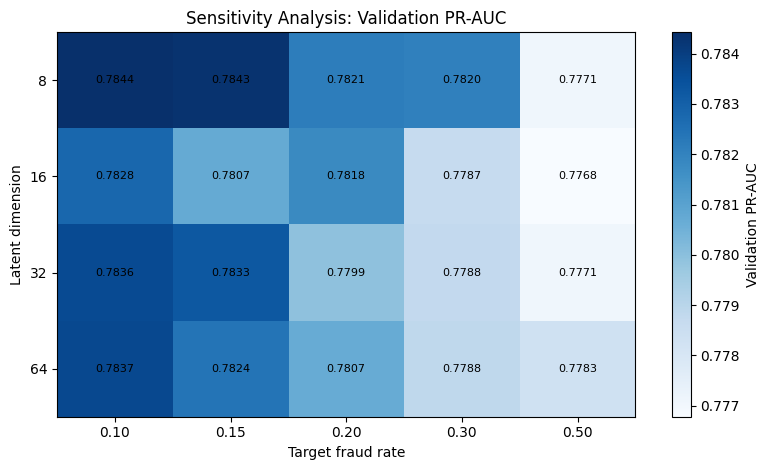

In [15]:
heatmap_df = sensitivity_df.pivot(
    index="latent_dim",
    columns="target_fraud_rate",
    values="validation_average_precision",
).sort_index()

fig, ax = plt.subplots(figsize=(8, 4.8))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="Blues")
ax.set_title("Sensitivity Analysis: Validation PR-AUC")
ax.set_xlabel("Target fraud rate")
ax.set_ylabel("Latent dimension")
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels([f"{value:.2f}" for value in heatmap_df.columns])
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        ax.text(j, i, f"{heatmap_df.iloc[i, j]:.4f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Validation PR-AUC")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sensitivity_validation_pr_auc_heatmap.png", dpi=200)
plt.show()

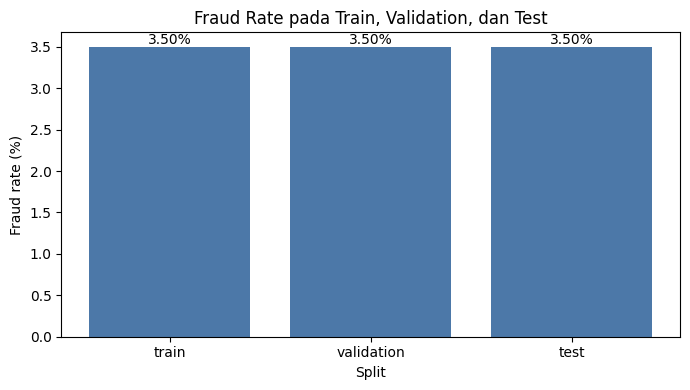

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(split_summary_df["split"], split_summary_df["fraud_rate"] * 100, color="#4C78A8")
ax.set_title("Fraud Rate pada Train, Validation, dan Test")
ax.set_ylabel("Fraud rate (%)")
ax.set_xlabel("Split")
for i, value in enumerate(split_summary_df["fraud_rate"] * 100):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "split_fraud_rate.png", dpi=200)
plt.show()

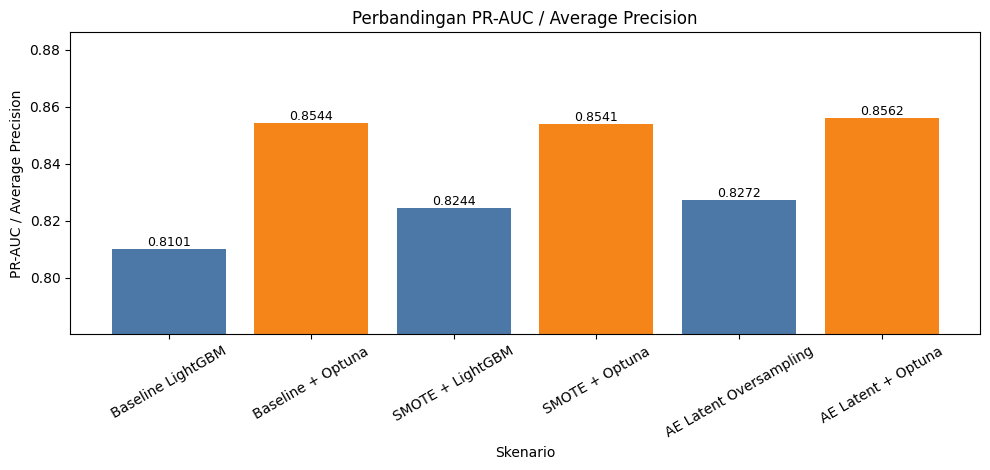

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = results_df.loc[available_order]
colors = ["#4C78A8" if not name.endswith("_tuned") else "#F58518" for name in plot_df.index]

ax.bar(plot_df["label"], plot_df["average_precision"], color=colors)
ax.set_title("Perbandingan PR-AUC / Average Precision")
ax.set_ylabel("PR-AUC / Average Precision")
ax.set_xlabel("Skenario")
ax.set_ylim(max(0.0, plot_df["average_precision"].min() - 0.03), min(1.0, plot_df["average_precision"].max() + 0.03))
ax.tick_params(axis="x", rotation=30)
for i, value in enumerate(plot_df["average_precision"]):
    ax.text(i, value, f"{value:.4f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "metrics_average_precision_bar.png", dpi=200)
plt.show()

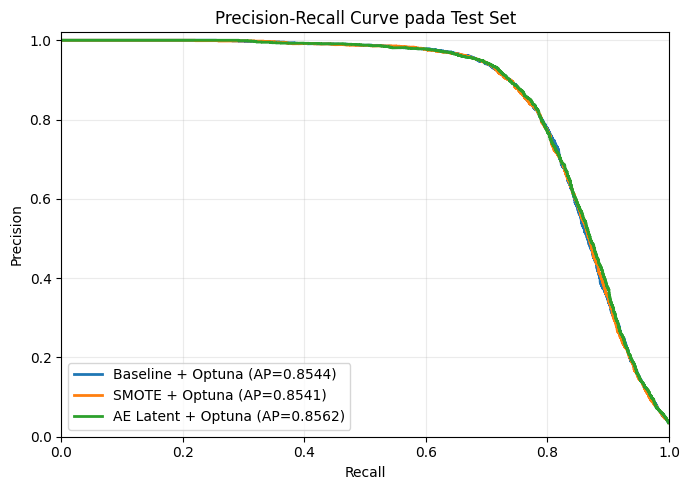

In [18]:
curve_scenarios = [name for name in ["baseline_tuned", "smote_tuned", "ae_oversample_tuned"] if name in score_store]
if not curve_scenarios:
    curve_scenarios = [name for name in ["baseline", "smote", "ae_oversample"] if name in score_store]

fig, ax = plt.subplots(figsize=(7, 5))
for name in curve_scenarios:
    precision, recall, _ = precision_recall_curve(y_test, score_store[name]["test"])
    ap = average_precision_score(y_test, score_store[name]["test"])
    ax.plot(recall, precision, linewidth=2, label=f"{SCENARIO_LABELS[name]} (AP={ap:.4f})")

ax.set_title("Precision-Recall Curve pada Test Set")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "precision_recall_curve_tuned.png", dpi=200)
plt.show()

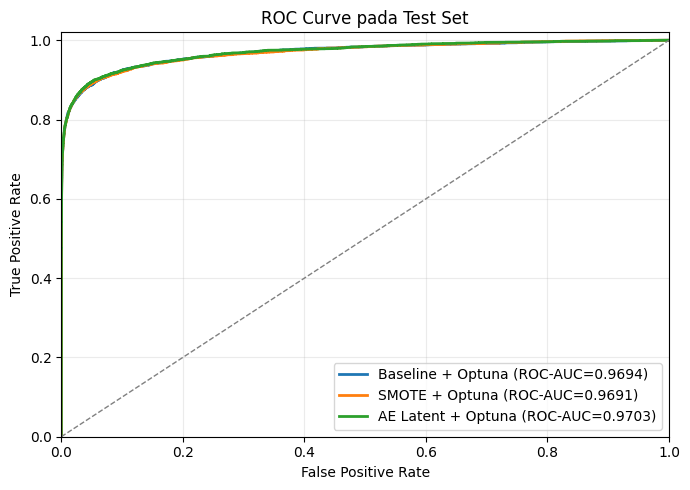

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in curve_scenarios:
    fpr, tpr, _ = roc_curve(y_test, score_store[name]["test"])
    roc = roc_auc_score(y_test, score_store[name]["test"])
    ax.plot(fpr, tpr, linewidth=2, label=f"{SCENARIO_LABELS[name]} (ROC-AUC={roc:.4f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("ROC Curve pada Test Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "roc_curve_tuned.png", dpi=200)
plt.show()

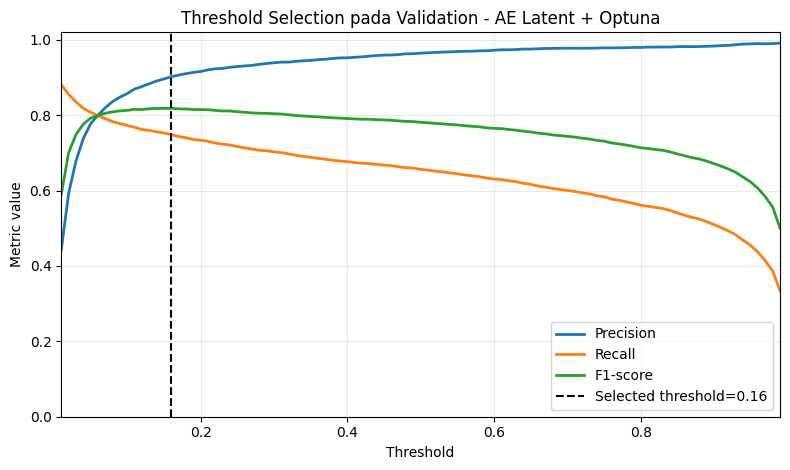

In [20]:
threshold_df = threshold_tables[best_scenario]
selected_threshold = float(results_df.loc[best_scenario, "selected_threshold"])

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-score", linewidth=2)
ax.axvline(selected_threshold, color="black", linestyle="--", linewidth=1.5, label=f"Selected threshold={selected_threshold:.2f}")
ax.set_title(f"Threshold Selection pada Validation - {SCENARIO_LABELS[best_scenario]}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Metric value")
ax.set_xlim(0.01, 0.99)
ax.set_ylim(0, 1.02)
ax.legend(loc="best")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_threshold_selection_best_model.png", dpi=200)
plt.show()

## 14. Catatan membaca hasil

Gunakan urutan interpretasi berikut saat menjelaskan notebook:

1. lihat split untuk memastikan proporsi fraud stabil;
2. lihat sensitivity analysis untuk menjelaskan mengapa `latent_dim` dan `target_fraud_rate` dikunci pada nilai tertentu;
3. lihat tabel hasil untuk membandingkan PR-AUC sebagai metrik utama;
4. bandingkan baseline, SMOTE, dan AE latent oversampling pada versi tuned;
5. gunakan kurva Precision-Recall untuk menjelaskan trade-off precision dan recall pada data tidak seimbang;
6. gunakan grafik threshold validation untuk menjelaskan bahwa F1 test memakai threshold yang dipilih dari validation, bukan dari test.